In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [205]:
df = pd.read_csv("D:/carrie works/SFU_Prepare/882/lab4/youtube_videos.csv")

load data

In [206]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [207]:
df.columns

Index(['video_id', 'title', 'category', 'channel_tier', 'upload_day',
       'upload_hour', 'duration_seconds', 'views', 'likes', 'comments',
       'shares', 'watch_time_minutes', 'avg_view_duration_seconds',
       'click_through_rate', 'channel_age_years', 'subscribers', 'tags_count',
       'hashtags'],
      dtype='object')

In [208]:
scaler = MinMaxScaler()

In [209]:
df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

In [210]:
df["subscribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

In [211]:
df["views_minmax"] = scaler.fit_transform(df[["views"]])

In [212]:
df["duration_seconds_minmax"] = scaler.fit_transform(df[["duration_seconds"]])

In [213]:
df["duration_seconds_minmax"].describe()

count    210.000000
mean       0.171440
std        0.182455
min        0.000000
25%        0.057011
50%        0.114444
75%        0.210008
max        1.000000
Name: duration_seconds_minmax, dtype: float64

<Axes: xlabel='duration_seconds_minmax', ylabel='Count'>

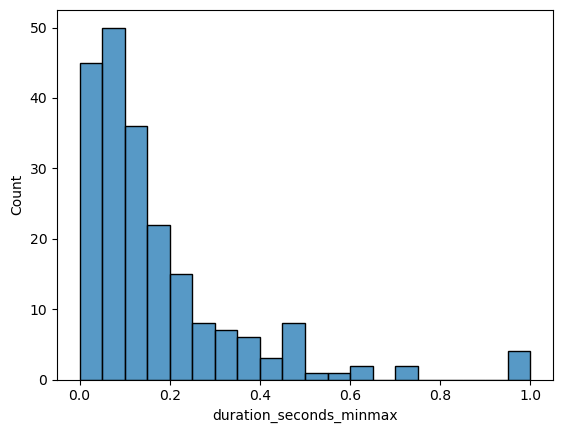

In [214]:
sns.histplot(df["duration_seconds_minmax"])

In [215]:
scaler_standard = StandardScaler()

In [216]:
df["views_zscore"] = scaler_standard.fit_transform(df[["views"]])

In [217]:
df["views_zscore"].describe()

count    2.100000e+02
mean     2.537653e-17
std      1.002389e+00
min     -4.481625e-01
25%     -4.404694e-01
50%     -3.952794e-01
75%     -1.946757e-01
max      5.316044e+00
Name: views_zscore, dtype: float64

In [218]:
df["watch_time_minutes_zscore"] = scaler_standard.fit_transform(df[["watch_time_minutes"]])

In [219]:
df["watch_time_minutes_zscore"].describe()

count    210.000000
mean       0.000000
std        1.002389
min       -0.222072
25%       -0.219983
50%       -0.212068
75%       -0.163687
max       10.988603
Name: watch_time_minutes_zscore, dtype: float64

<Axes: xlabel='watch_time_minutes_zscore', ylabel='Count'>

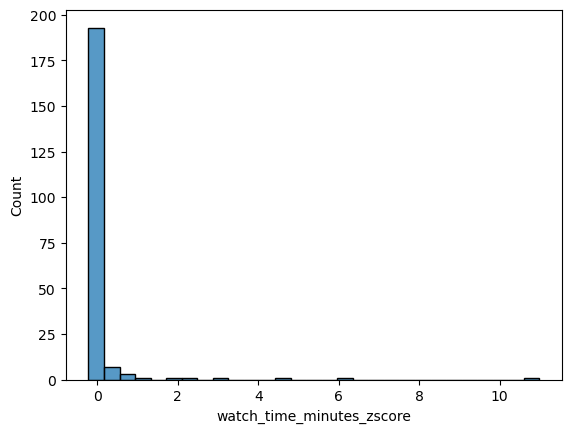

In [220]:
sns.histplot(df["watch_time_minutes_zscore"])

In [221]:
scaler_robust = RobustScaler()

In [222]:
df["likes_robust"] = scaler_robust.fit_transform(df[["likes"]])

In [223]:
df["likes_robust"].describe()

count    210.000000
mean       1.959849
std        5.509473
min       -0.180586
25%       -0.142676
50%        0.000000
75%        0.857324
max       37.685244
Name: likes_robust, dtype: float64

In [224]:
df["comments_robust"] = scaler_robust.fit_transform(df[["comments"]])

In [225]:
df["comments_robust"].describe()

count    210.000000
mean       1.695177
std        4.273323
min       -0.134695
25%       -0.106231
50%        0.000000
75%        0.893769
max       33.191832
Name: comments_robust, dtype: float64

<Axes: xlabel='comments_robust', ylabel='Count'>

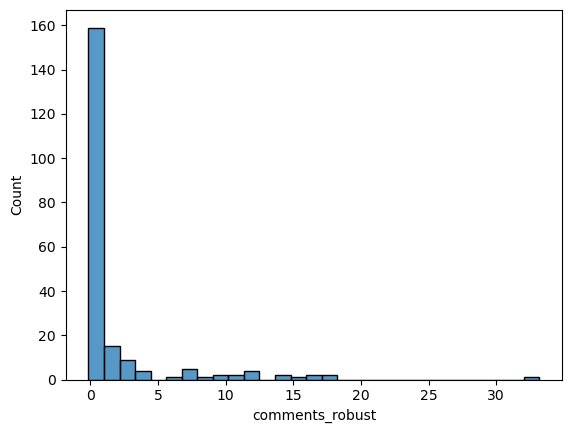

In [226]:
sns.histplot(df["comments_robust"])

In [227]:
df["views_log"]= np.log1p(df["views"])

In [228]:
df["views_log"].describe()

count    210.000000
mean      11.146775
std        2.175266
min        7.253470
25%        9.287764
50%       11.096972
75%       12.645811
max       15.766913
Name: views_log, dtype: float64

<Axes: xlabel='views_log', ylabel='Count'>

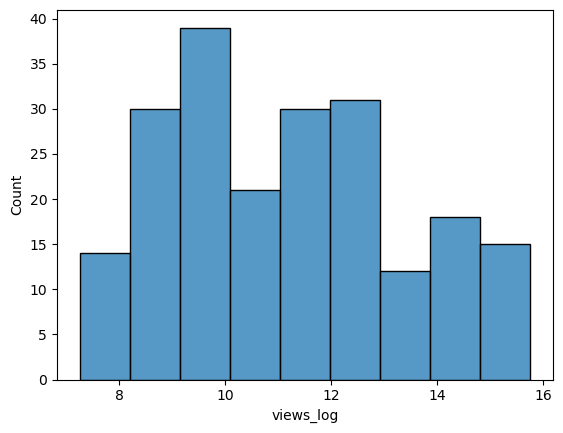

In [229]:
sns.histplot(df["views_log"])

Bining

C:\Users\ELSAL\AppData\Local\Temp\ipykernel_18464\818591122.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


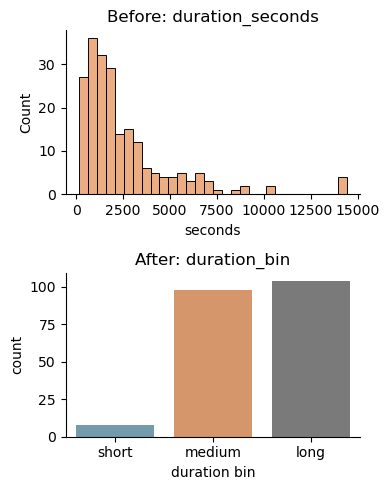

In [230]:
bins = [0, 300, 1800, float("inf")]
labels = ["short", "medium", "long"]

df["duration_bin"] = pd.cut(
    df["duration_seconds"],
    bins=bins,
    labels=labels
)

order = ["short", "medium", "long"]
colors = ["#6a9fb5", "#e8925a", "#7a7a7a"]

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["duration_seconds"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: duration_seconds")
axes[0].set_xlabel("seconds")

sns.countplot(data=df,
              x="duration_bin",
              order=order,
              palette=colors,
              ax=axes[1])
axes[1].set_title("After: duration_bin")
axes[1].set_xlabel("duration bin")
axes[1].set_ylabel("count")

sns.despine()
plt.tight_layout()
plt.show()

In [231]:
bins = [0,100,400, float("inf")]
labels = ["no_shares", "moderate_shares", "sig_shares"]
df["share_bins"]= pd.cut(df["shares"], bins=bins, labels= labels)

C:\Users\ELSAL\AppData\Local\Temp\ipykernel_18464\917712578.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


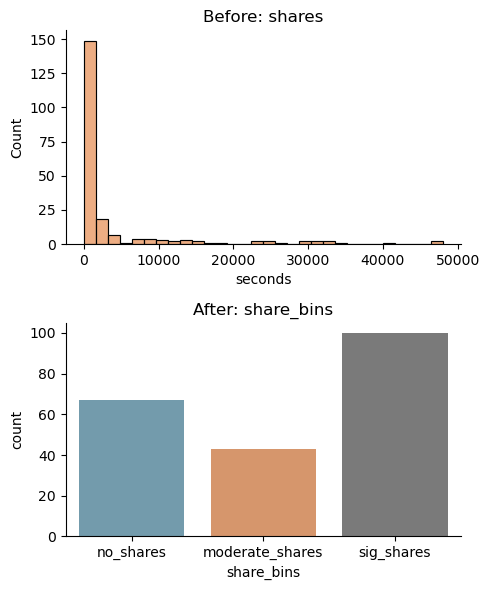

In [232]:
order = ["no_shares", "moderate_shares", "sig_shares"]
colors = ["#6a9fb5", "#e8925a", "#7a7a7a"]

fig, axes = plt.subplots(2, 1, figsize=(5, 6))

sns.histplot(df["shares"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: shares")
axes[0].set_xlabel("seconds")

sns.countplot(data=df,
              x="share_bins",
              order=order,
              palette=colors,
              ax=axes[1])
axes[1].set_title("After: share_bins")
axes[1].set_xlabel("share_bins")
axes[1].set_ylabel("count")

sns.despine()
plt.tight_layout()
plt.show()

In [233]:
df["channel_tier"].unique()

array(['Mid', 'Small', 'Large'], dtype=object)

In [234]:
encoder = OrdinalEncoder(categories= [["Small", "Mid", "Large"]])

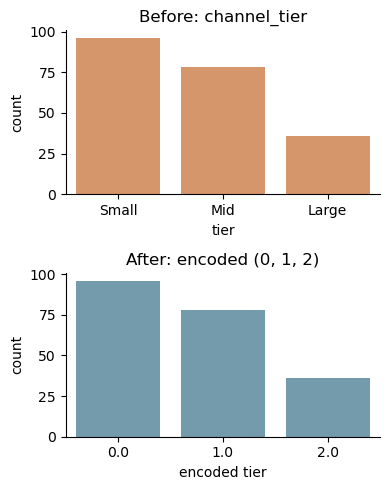

In [235]:
df["channel_tier_encoded"] = encoder.fit_transform(
    df[["channel_tier"]]
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

order_str = ["Small", "Mid", "Large"]
sns.countplot(data=df,
              x="channel_tier",
              order=order_str,
              color="#e8925a",
              ax=axes[0])
axes[0].set_title("Before: channel_tier")
axes[0].set_xlabel("tier")

order_num = [0, 1, 2]
sns.countplot(data=df,
              x="channel_tier_encoded",
              color="#6a9fb5",
              ax=axes[1])
axes[1].set_title("After: encoded (0, 1, 2)")
axes[1].set_xlabel("encoded tier")

sns.despine()
plt.tight_layout()
plt.show()

In [236]:
dummyvar= pd.get_dummies(df["category"], prefix = "is")

In [237]:
dummyvar.head()

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False


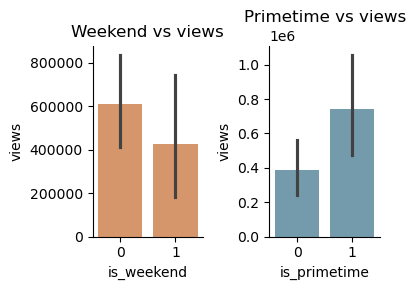

In [238]:
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

# extract features from timestamp
df["is_weekend"] = (df["uploaded_at"].dt.dayofweek >= 5).astype(int)
df["is_primetime"] = (
    (df["uploaded_at"].dt.hour >= 18) &
    (df["uploaded_at"].dt.hour <= 22)
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(4, 3))

sns.barplot(data=df,
            x="is_weekend",
            y="views",
            color="#e8925a",
            ax=axes[0])
axes[0].set_title("Weekend vs views")
axes[0].set_xlabel("is_weekend")

sns.barplot(data=df,
            x="is_primetime",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("Primetime vs views")
axes[1].set_xlabel("is_primetime")

sns.despine()
plt.tight_layout()
plt.show()

In [254]:
df["caps_count"] =  df["title"].apply(
    lambda t: np.sum(1 for w in t.split() if w.isupper())
)

C:\Users\ELSAL\AppData\Local\Temp\ipykernel_18464\1288324224.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  lambda t: np.sum(1 for w in t.split() if w.isupper())


In [255]:
df["caps_count"]

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: caps_count, Length: 210, dtype: int64

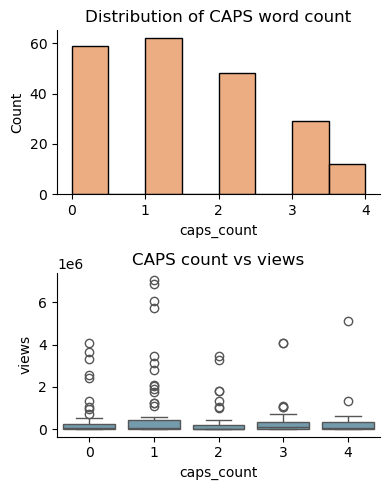

In [256]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["caps_count"],
             bins=8,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of CAPS word count")
axes[0].set_xlabel("caps_count")

sns.boxplot(data=df,
            x="caps_count",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("CAPS count vs views")
axes[1].set_xlabel("caps_count")
axes[1].set_ylabel("views")

sns.despine()
plt.tight_layout()
plt.show()

In [251]:
# def coutCaps(t):
#     total_sum =0
#     words=t.split()
#     for word in words:
#         if (word.isupper):
#             total_sum = +1
#     return total_sum 

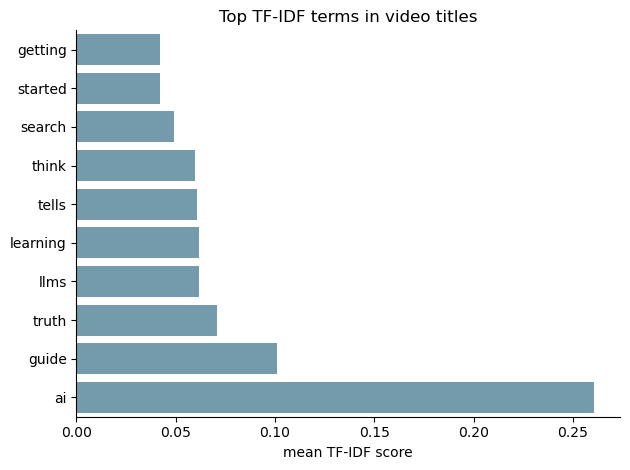

In [243]:
vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

In [244]:
df["duration_min"] = df["duration_seconds"] /60

In [245]:
df["ret_rate"] = (
    df["watch_time_minutes"] /
    (df["views"] * df["duration_min"])
).clip(0, 1)

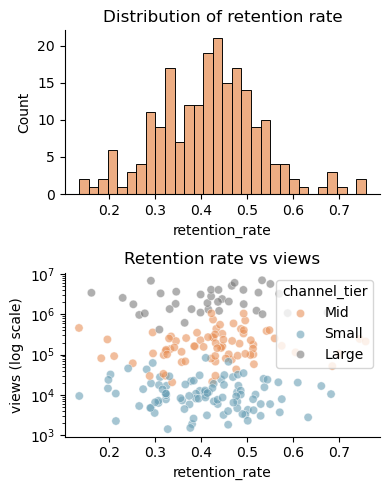

In [246]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["ret_rate"],
             bins=30,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of retention rate")
axes[0].set_xlabel("retention_rate")

sns.scatterplot(data=df,
                x="ret_rate",
                y="views",
                hue="channel_tier",
                palette={"Small": "#6a9fb5",
                         "Mid": "#e8925a",
                         "Large": "#7a7a7a"},
                alpha=0.6,
                ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Retention rate vs views")
axes[1].set_xlabel("retention_rate")
axes[1].set_ylabel("views (log scale)")

sns.despine()
plt.tight_layout()
plt.show()

In [247]:
df["reach_potential"] = (
    df["subscribers"] * df["click_through_rate"]
)

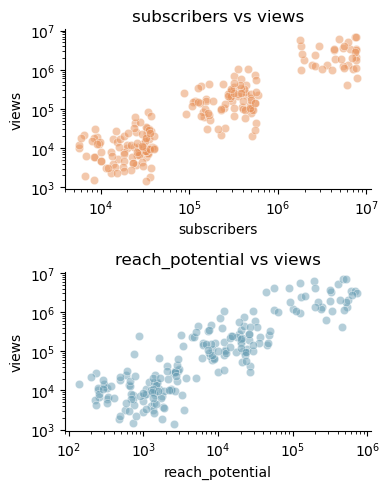

In [248]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.scatterplot(data=df,
                x="subscribers",
                y="views",
                color="#e8925a",
                alpha=0.5,
                ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("subscribers vs views")

sns.scatterplot(data=df,
                x="reach_potential",
                y="views",
                color="#6a9fb5",
                alpha=0.5,
                ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("reach_potential vs views")

sns.despine()
plt.tight_layout()
plt.show()

In [249]:
df["hashtags"] = df["hashtags"].apply(json.loads)

In [250]:
mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
